In [3]:
##### Config #####
CONFIG_ROUNDS: int = 7
CONFIG_CLIENTS: int = 5
CONFIG_SHAP_SAMPLE: int = 25
##################

import os
# -------------------------
# Determinism / Reproducibility
# -------------------------
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
random.seed(seed_value)

import numpy as np
np.random.seed(seed_value)

import tensorflow as tf
tf.random.set_seed(seed_value)

try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except Exception:
    pass

# -------------------------
# Imports
# -------------------------
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import shap
import matplotlib.pyplot as plt
import warnings
import glob
import pandas as pd
warnings.filterwarnings('ignore')

# =====================================================
# Federated XAI IDS (Deep MLP Version)
# =====================================================
class FederatedXAIIDS:
    def __init__(self, num_clients=4, input_dim=46, num_classes=6, batch_size=500000):
        self.num_clients = num_clients
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.batch_size = batch_size
        self.client_models = []
        self.global_model = None
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()

    # -----------------------------------------------------
    # Deep MLP Model (Alternative 2)
    # -----------------------------------------------------
    def create_model(self):
        model = keras.Sequential([
            # Input Layer এবং ১ম ডেন্স লেয়ার
            layers.Dense(256, activation='relu', input_shape=(self.input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),

            # ২য় ডেন্স লেয়ার
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),

            # ৩য় ডেন্স লেয়ার
            layers.Dense(64, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),

            # আউটপুট লেয়ার
            layers.Dense(self.num_classes, activation='softmax')
        ])

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    # -----------------------------------------------------
    # Process data files in batches
    # -----------------------------------------------------
    def process_files_in_batches(self, folder_path, file_pattern="*.csv", max_files=8, max_samples=None):
        print("Processing LIMITED files for testing...")

        csv_files = sorted(glob.glob(os.path.join(folder_path, file_pattern)))
        if not csv_files:
            raise ValueError(f"No CSV files found in {folder_path}")

        csv_files = csv_files[:max_files]
        print(f"Using {len(csv_files)} out of {len(glob.glob(os.path.join(folder_path, file_pattern)))} files for testing")

        print("Fitting preprocessing on sample data...")
        sample_data = self._get_sample_for_preprocessing(csv_files, sample_size=10000)
        self._fit_preprocessors(sample_data)

        all_client_data = {f'client_{i}': {'X_train': [], 'X_test': [], 'y_train': [], 'y_test': []}
                          for i in range(self.num_clients)}

        total_processed = 0

        for file_idx, csv_file in enumerate(csv_files):
            print(f"Processing file {file_idx+1}/{len(csv_files)}: {os.path.basename(csv_file)}")

            try:
                for chunk in pd.read_csv(csv_file, chunksize=self.batch_size, low_memory=False):
                    if max_samples and total_processed >= max_samples:
                        print(f"Reached maximum sample limit of {max_samples}")
                        break

                    X_processed, y_processed = self._process_chunk(chunk)
                    if X_processed is not None:
                        chunk_client_data = self._split_chunk_among_clients(X_processed, y_processed)
                        for client_id, data in chunk_client_data.items():
                            all_client_data[client_id]['X_train'].append(data['X_train'])
                            all_client_data[client_id]['X_test'].append(data['X_test'])
                            all_client_data[client_id]['y_train'].append(data['y_train'])
                            all_client_data[client_id]['y_test'].append(data['y_test'])
                        total_processed += len(X_processed)
                        print(f"  Processed {total_processed} samples so far...")
            except Exception as e:
                print(f"Error processing {csv_file}: {e}")
                continue

            if max_samples and total_processed >= max_samples:
                break

        # Combine chunks for each client
        final_client_data = []
        for client_id in range(self.num_clients):
            client_key = f'client_{client_id}'
            if (all_client_data[client_key]['X_train'] and
                len(all_client_data[client_key]['X_train'][0]) > 0):

                X_train = np.vstack(all_client_data[client_key]['X_train'])
                X_test = np.vstack(all_client_data[client_key]['X_test'])
                y_train = np.vstack(all_client_data[client_key]['y_train'])
                y_test = np.vstack(all_client_data[client_key]['y_test'])

                final_client_data.append({
                    'X_train': X_train,
                    'X_test': X_test,
                    'y_train': y_train,
                    'y_test': y_test
                })
                print(f"Client {client_id+1}: {len(X_train)} training, {len(X_test)} test samples")
            else:
                final_client_data.append({
                    'X_train': np.array([]).reshape(0, self.input_dim),
                    'X_test': np.array([]).reshape(0, self.input_dim),
                    'y_train': np.array([]).reshape(0, self.num_classes),
                    'y_test': np.array([]).reshape(0, self.num_classes)
                })
        print(f"Total processed samples: {total_processed}")
        return final_client_data

    # -----------------------------------------------------
    # Helper functions
    # -----------------------------------------------------
    def _get_sample_for_preprocessing(self, csv_files, sample_size=10000):
        sample_data, total_samples = [], 0
        for csv_file in csv_files:
            if total_samples >= sample_size:
                break
            try:
                df_sample = pd.read_csv(csv_file, nrows=min(2000, max(1, sample_size//len(csv_files))), low_memory=False)
                sample_data.append(df_sample)
                total_samples += len(df_sample)
            except Exception:
                continue
        if sample_data:
            return pd.concat(sample_data, ignore_index=True)
        else:
            raise ValueError("Could not load sample data for preprocessing")

    def _fit_preprocessors(self, sample_data):
        print("Fitting preprocessing objects...")
        sample_data = self._clean_data_chunk(sample_data)
        timestamp_cols = [c for c in sample_data.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
        if timestamp_cols:
            sample_data = sample_data.drop(timestamp_cols, axis=1)
        target_col = self._identify_target_column(sample_data)
        X_sample = sample_data.drop(target_col, axis=1)
        y_sample = sample_data[target_col]
        self.input_dim = X_sample.shape[1]
        print(f"Input dimension set to: {self.input_dim}")
        y_sample = self._convert_to_six_classes(y_sample)
        self.scaler.fit(X_sample)
        self.label_encoder.fit(y_sample)
        print("Preprocessing objects fitted successfully")
        print(f"Classes: {list(self.label_encoder.classes_)}")

    def _process_chunk(self, chunk):
        chunk_clean = self._clean_data_chunk(chunk)
        if chunk_clean.empty:
            return None, None
        timestamp_cols = [c for c in chunk_clean.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
        if timestamp_cols:
            chunk_clean = chunk_clean.drop(timestamp_cols, axis=1)
        target_col = self._identify_target_column(chunk_clean)
        X = chunk_clean.drop(target_col, axis=1)
        y = chunk_clean[target_col]
        y = self._convert_to_six_classes(y)
        X_processed = self.scaler.transform(X)
        y_encoded = self.label_encoder.transform(y)
        y_processed = keras.utils.to_categorical(y_encoded, self.num_classes)
        return X_processed, y_processed

    def _clean_data_chunk(self, df_chunk):
        for col in df_chunk.select_dtypes(include=['object']).columns:
            if col not in ['Label', 'label', 'attack', 'class']:
                try:
                    df_chunk[col] = pd.to_numeric(df_chunk[col], errors='coerce')
                except:
                    pass
        df_chunk = df_chunk.replace([np.inf, -np.inf], np.nan)
        df_chunk = df_chunk.dropna()
        return df_chunk

    def _identify_target_column(self, df):
        for c in ['label', 'Label', 'attack', 'Attack', 'class', 'Class']:
            if c in df.columns:
                return c
        return df.columns[-1]

    def _split_chunk_among_clients(self, X_chunk, y_chunk):
        chunk_size = len(X_chunk)
        if chunk_size == 0:
            return {}
        samples_per_client = chunk_size // self.num_clients
        client_data = {}
        for i in range(self.num_clients):
            start_idx, end_idx = i * samples_per_client, (i + 1) * samples_per_client
            if i == self.num_clients - 1:
                end_idx = chunk_size
            if start_idx < end_idx:
                X_client, y_client = X_chunk[start_idx:end_idx], y_chunk[start_idx:end_idx]
                if len(X_client) > 1:
                    X_train, X_test, y_train, y_test = train_test_split(
                        X_client, y_client, test_size=0.2, random_state=seed_value
                    )
                    client_data[f'client_{i}'] = {
                        'X_train': X_train,
                        'X_test': X_test,
                        'y_train': y_train,
                        'y_test': y_test
                    }
                else:
                    client_data[f'client_{i}'] = {
                        'X_train': X_client,
                        'X_test': np.array([]).reshape(0, self.input_dim),
                        'y_train': y_client,
                        'y_test': np.array([]).reshape(0, self.num_classes)
                    }
        return client_data

    def _convert_to_six_classes(self, y):
        y_str = y.astype(str).str.lower()
        class_mapping = {}
        for lbl in y_str.unique():
            lbl_low = lbl.lower()
            if any(k in lbl_low for k in ['benign', 'normal', 'legitimate']):
                class_mapping[lbl] = 'Benign'
            elif any(k in lbl_low for k in ['ddos', 'distributed denial']):
                class_mapping[lbl] = 'DDoS'
            elif any(k in lbl_low for k in ['dos', 'denial of service']):
                class_mapping[lbl] = 'DoS'
            elif 'mirai' in lbl_low:
                class_mapping[lbl] = 'Mirai'
            elif any(k in lbl_low for k in ['recon', 'scan', 'portscan', 'hostscan']):
                class_mapping[lbl] = 'Recon'
            else:
                class_mapping[lbl] = 'Other'
        return y_str.map(class_mapping)

    # -----------------------------------------------------
    # Federated Training
    # -----------------------------------------------------
    def federated_training(self, client_data, rounds=5, epochs=10):
        print("\nStarting Federated Training (TEST MODE)...")
        self.global_model = self.create_model()
        global_weights = self.global_model.get_weights()
        accuracy_trends = {f'client_{i}': [] for i in range(self.num_clients)}

        for r in range(rounds):
            print(f"\n--- Federated Round {r+1} ---")
            client_weights, client_samples = [], []
            for i, data in enumerate(client_data):
                if len(data['X_train']) == 0:
                    print(f"Client {i+1}: No data, skipping...")
                    continue
                print(f"Training Client {i+1}...")
                local_model = self.create_model()
                local_model.set_weights(global_weights)
                history = local_model.fit(
                    data['X_train'], data['y_train'],
                    epochs=epochs, batch_size=256,
                    validation_data=(data['X_test'], data['y_test']),
                    verbose=0
                )
                acc = history.history['val_accuracy'][-1]
                accuracy_trends[f'client_{i}'].append(acc)
                client_weights.append(local_model.get_weights())
                client_samples.append(len(data['X_train']))
                print(f"Client {i+1} accuracy: {acc:.4f}")

            if client_weights:
                print("Aggregating weights with FedAvg...")
                new_global_weights = []
                total_samples = sum(client_samples)
                for weights in zip(*client_weights):
                    agg = np.zeros_like(weights[0])
                    for w, n in zip(weights, client_samples):
                        agg += w * (n / total_samples)
                    new_global_weights.append(agg)
                global_weights = new_global_weights
                self.global_model.set_weights(global_weights)

            global_acc = self.evaluate_global_model(client_data)
            print(f"Global model accuracy after round {r+1}: {global_acc:.4f}")
        return accuracy_trends

    # -----------------------------------------------------
    # Evaluate Global Model
    # -----------------------------------------------------
    def evaluate_global_model(self, client_data):
        X_test_all, y_test_all = [], []
        for d in client_data:
            if len(d['X_test']) > 0:
                X_test_all.append(d['X_test'])
                y_test_all.append(d['y_test'])
        if not X_test_all:
            return 0.0
        X_test, y_test = np.vstack(X_test_all), np.vstack(y_test_all)
        loss, acc = self.global_model.evaluate(X_test, y_test, verbose=0)
        return acc

    # -----------------------------------------------------
    # Train and Evaluate
    # -----------------------------------------------------
    def train_and_evaluate(self, data_folder, file_pattern="*.csv"):
        client_data = self.process_files_in_batches(data_folder, file_pattern)
        accuracy_trends = self.federated_training(client_data, rounds=CONFIG_ROUNDS, epochs=10)

        print("\n" + "="*50)
        print("TEST MODE - FINAL EVALUATION")
        print("="*50)
        final_acc = self.evaluate_global_model(client_data)
        print(f"Final Global Model Test Accuracy: {final_acc:.4f}")

        X_test_all, y_test_all = [], []
        for d in client_data:
            if len(d['X_test']) > 0:
                X_test_all.append(d['X_test'])
                y_test_all.append(d['y_test'])
        if X_test_all:
            X_test, y_test = np.vstack(X_test_all), np.vstack(y_test_all)
            y_pred = self.global_model.predict(X_test, verbose=0)
            y_pred_classes = np.argmax(y_pred, axis=1)
            y_true_classes = np.argmax(y_test, axis=1)
            print("\nClassification Report:")
            print(classification_report(y_true_classes, y_pred_classes, target_names=self.label_encoder.classes_))
            print(f"Overall Accuracy: {accuracy_score(y_true_classes, y_pred_classes):.4f}")

        # SHAP Explainability
        print("\n" + "="*60)
        print("🔍 Applying SHAP (Kernel SHAP) for Global Explainability")
        print("="*60)
        try:
            sample_size = min(CONFIG_SHAP_SAMPLE, X_test.shape[0])
            rng = np.random.default_rng(seed_value)
            shap_idx = rng.choice(X_test.shape[0], sample_size, replace=False)
            X_shap = X_test[shap_idx]
            background_size = min(100, X_test.shape[0])
            background_idx = rng.choice(X_test.shape[0], background_size, replace=False)
            X_bg = X_test[background_idx]
            explainer = shap.KernelExplainer(self.global_model.predict, X_bg)
            shap_vals = explainer.shap_values(X_shap, nsamples=100)
            shap.summary_plot(shap_vals, X_shap, show=False, plot_type="bar")
            plt.title("Global Feature Importance (SHAP - Kernel Explainer)")
            plt.tight_layout()
            plt.savefig("shap_global_feature_importance_bar.png")
            plt.close()
            shap.summary_plot(shap_vals, X_shap, show=False)
            plt.title("Global SHAP Summary (Feature Impact on Predictions)")
            plt.tight_layout()
            plt.savefig("shap_global_summary_dot.png")
            plt.close()
            print("📊 SHAP summary plots saved successfully.")
        except Exception as e:
            print(f"⚠️ SHAP explainability failed: {e}")

        return self.global_model, accuracy_trends

# =====================================================
# Run Federated MLP IDS
# =====================================================
if __name__ == "__main__":
    fed_xai_ids = FederatedXAIIDS(num_clients=CONFIG_CLIENTS, input_dim=46, num_classes=6, batch_size=500000)
    data_folder = r"CICIoT2023"
    file_pattern = "*.csv"

    try:
        print("=== TEST MODE: Federated MLP XAI IDS Training with LIMITED DATASET ===")
        print("Using only a deterministic subset of files for quick testing")
        print("=" * 70)
        global_model, accuracy_trends = fed_xai_ids.train_and_evaluate(data_folder, file_pattern)

        global_model.save("fedxaiids_MLP_TEST.h5")
        print("Model saved as 'fedxaiids_MLP_TEST.h5'")

        import joblib
        joblib.dump(fed_xai_ids.scaler, 'scaler_TEST.pkl')
        joblib.dump(fed_xai_ids.label_encoder, 'label_encoder_TEST.pkl')
        print("Preprocessing objects saved")

        print("\n" + "="*50)
        print("TEST COMPLETED SUCCESSFULLY!")
        print("="*50)
    except Exception as e:
        print(f"Error during testing: {e}")
        import traceback
        traceback.print_exc()

=== TEST MODE: Federated MLP XAI IDS Training with LIMITED DATASET ===
Using only a deterministic subset of files for quick testing
Processing LIMITED files for testing...
Using 1 out of 1 files for testing
Fitting preprocessing on sample data...
Fitting preprocessing objects...
Input dimension set to: 46
Preprocessing objects fitted successfully
Classes: ['Benign', 'DDoS', 'DoS', 'Mirai', 'Other', 'Recon']
Processing file 1/1: train_data.csv
  Processed 218805 samples so far...
Client 1: 35008 training, 8753 test samples
Client 2: 35008 training, 8753 test samples
Client 3: 35008 training, 8753 test samples
Client 4: 35008 training, 8753 test samples
Client 5: 35008 training, 8753 test samples
Total processed samples: 218805

Starting Federated Training (TEST MODE)...

--- Federated Round 1 ---
Training Client 1...
Client 1 accuracy: 0.8836
Training Client 2...
Client 2 accuracy: 0.8774
Training Client 3...
Client 3 accuracy: 0.8768
Training Client 4...
Client 4 accuracy: 0.8807
Train

  0%|          | 0/25 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
313/313 ━━━━━━

📊 SHAP summary plots saved successfully.
Model saved as 'fedxaiids_MLP_TEST.h5'
Preprocessing objects saved

TEST COMPLETED SUCCESSFULLY!


In [5]:
accuracy_df = pd.DataFrame(accuracy_trends)
accuracy_df.to_csv('accuracy_trends.csv', index=False)
print("Accuracy trends saved to 'accuracy_trends.csv'")

Accuracy trends saved to 'accuracy_trends.csv'


In [9]:
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

# ==========================================
# 1. Load the Pre-trained Model & Preprocessors
# ==========================================
model_path = "fedxaiids_MLP_TEST.h5"
scaler_path = "scaler_TEST.pkl"
encoder_path = "label_encoder_TEST.pkl"

print("Loading saved artifacts...")
model = tf.keras.models.load_model(model_path)
scaler = joblib.load(scaler_path)
label_encoder = joblib.load(encoder_path)

# Inspect the architecture (Expected input dim: (None, 46))
model.summary()

# ==========================================
# 2. Setup Meta-parameters from Model Input
# ==========================================
# Dynamic retrieval of expected feature size from the model layer
input_dim = model.input_shape[1]
print(f"\nModel expects {input_dim} numerical features per sample.")

# ==========================================
# 3. Choose your Input Data Source
# ==========================================
USE_REAL_DATA = True  # Flip to True if you want to test an actual CSV snippet

if USE_REAL_DATA:
    # Example: Reading a real line from your CICIoT2023 files
    csv_file_path = "test_data.csv"

    # Read just a tiny snippet for prediction
    df_chunk = pd.read_csv(csv_file_path, nrows=5, low_memory=False, on_bad_lines='skip')

    # Replicate your script's exact cleaning routine
    for col in df_chunk.select_dtypes(include=["object"]).columns:
        if col not in ["Label", "label", "attack", "class"]:
            df_chunk[col] = pd.to_numeric(df_chunk[col], errors="coerce")
    df_chunk = df_chunk.replace([np.inf, -np.inf], np.nan).dropna()

    # Identify and drop target labels & timestamps
    timestamp_cols = [
        c for c in df_chunk.columns if "time" in c.lower() or "timestamp" in c.lower()
    ]
    if timestamp_cols:
        df_chunk = df_chunk.drop(timestamp_cols, axis=1)

    if df_chunk.empty:
        print("\nNo valid samples remaining after cleaning. Skipping inference.")
        X_raw = np.array([]).reshape(0, input_dim) # Initialize X_raw as an empty array with correct dimensions
    else:
        target_col = next(
            (
                c
                for c in ["label", "Label", "attack", "Attack", "class", "Class"]
                if c in df_chunk.columns
            ),
            df_chunk.columns[-1], # This will now be safe as df_chunk is not empty
        )
        X_raw = df_chunk.drop(target_col, axis=1).values

    print(f"\nLoaded {len(X_raw)} real sample(s) from CSV.")
else:
    # Generate mock unscaled data mirroring your tabular features
    print("\nGenerating mock unscaled feature data...")
    X_raw = np.random.rand(1, input_dim).astype(np.float32)

# ==========================================
# 4. Preprocess Data & Run Inference
# ==========================================
if X_raw.shape[0] > 0: # Only proceed if there are samples to process
    # Step A: Standardize features using the training pipeline's scaler
    X_scaled = scaler.transform(X_raw)

    # Step B: Pass into the model (it handles its own internal reshaping to (46, 1) inside the first layer)
    raw_predictions = model.predict(X_scaled)

    # Step C: Parse Softmax distributions into human-readable text classes
    predicted_classes_idx = np.argmax(raw_predictions, axis=1)
    predicted_labels = label_encoder.inverse_transform(predicted_classes_idx)

    # ==========================================
    # 5. Output Results
    # ==========================================
    print("\n" + "=" * 40)
    print("INFERENCE RESULTS")
    print("=" * 40)
    for i, (prob, lbl) in enumerate(zip(raw_predictions, predicted_labels)):
        print(f"Sample {i + 1}:")
        print(f"  -> Predicted Class: {lbl}")
        print(f"  -> Confidence Distribution: {prob}")
else:
    print("\nNo samples to perform inference on.")

Loading saved artifacts...


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,368 (216.29 KB)

 Trainable params: 54,470 (212.77 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 2 (12.00 B)


Model expects 46 numerical features per sample.

Loaded 5 real sample(s) from CSV.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step

INFERENCE RESULTS
Sample 1:
  -> Predicted Class: DDoS
  -> Confidence Distribution: [3.5713404e-06 9.9984705e-01 1.3501584e-04 1.9721970e-06 8.4895928e-06
 3.7753659e-06]
Sample 2:
  -> Predicted Class: DDoS
  -> Confidence Distribution: [3.6614799e-06 9.9983871e-01 1.4331345e-04 2.0151715e-06 8.4149533e-06
 3.8502626e-06]
Sample 3:
  -> Predicted Class: DDoS
  -> Confidence Distribution: [4.3677196e-06 9.9979311e-01 1.8643658e-04 2.5578665e-06 9.1666698e-06
 4.4211947e-06]
Sample 4:
  -> Predicted Class: DDoS
  -> Confidence Distribution: [3.56280634e-06 9.99870181e-01 1.12214155e-04 1.94621907e-06
 8.54738028e-06 3.62883793e-06]
Sample 5:
  -> Predicted Class: DDoS
  -> Confidence Distribution: [3.5799983e-06 9.9984694e-01 1.3519995e-04 1.9780150e-06 8.5102547e-06
 3.7839011e-06]


## Federated Learning Analysis: Accuracy Trends, Impedances, and Risk

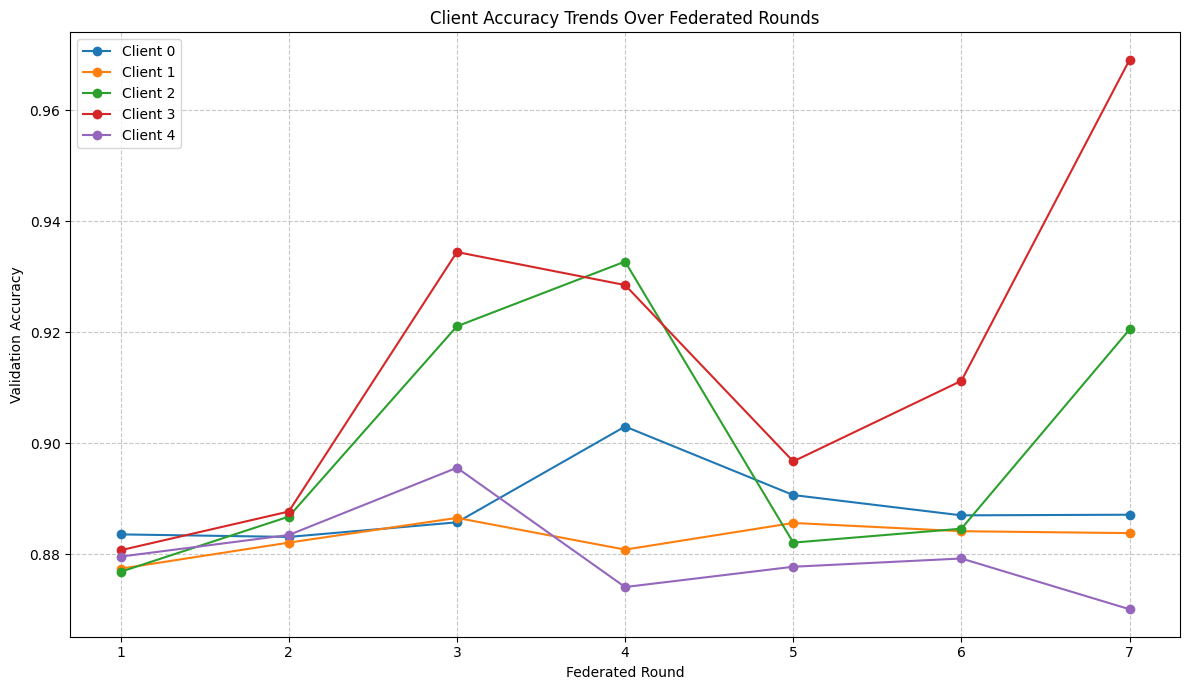

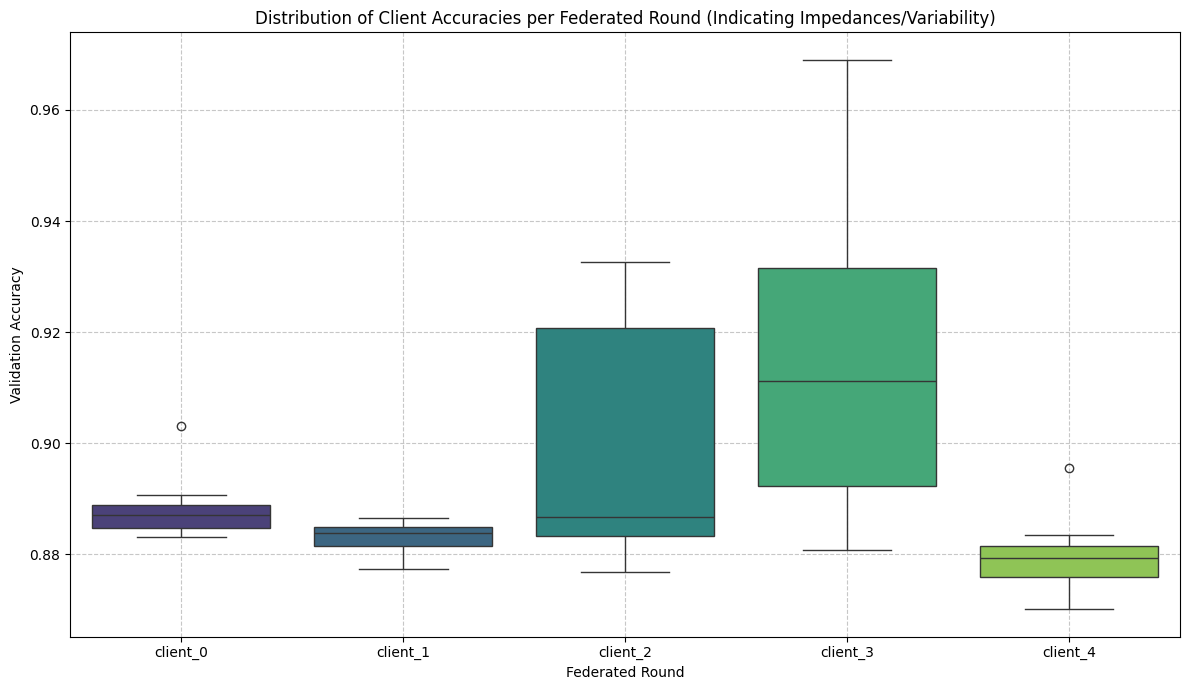

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize accuracy trends per client
plt.figure(figsize=(12, 7))
for client_id in accuracy_df.columns:
    plt.plot(accuracy_df.index + 1, accuracy_df[client_id], marker='o', label=f'Client {client_id.split("_")[1]}')

plt.title('Client Accuracy Trends Over Federated Rounds')
plt.xlabel('Federated Round')
plt.ylabel('Validation Accuracy')
plt.xticks(accuracy_df.index + 1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# For 'Impedances', we can look at the spread of accuracies per round
plt.figure(figsize=(12, 7))
sns.boxplot(data=accuracy_df, palette='viridis')
plt.title('Distribution of Client Accuracies per Federated Round (Indicating Impedances/Variability)')
plt.xlabel('Federated Round')
plt.ylabel('Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Risk Analysis: Classification Report Metrics

To perform 'risk analysis', we'll visualize the model's performance on different attack classes (Benign, DDoS, DoS, Mirai, Other, Recon). This shows how well the model identifies each type, which is critical for an IDS. For example, a low recall for a severe attack type would indicate a high risk.

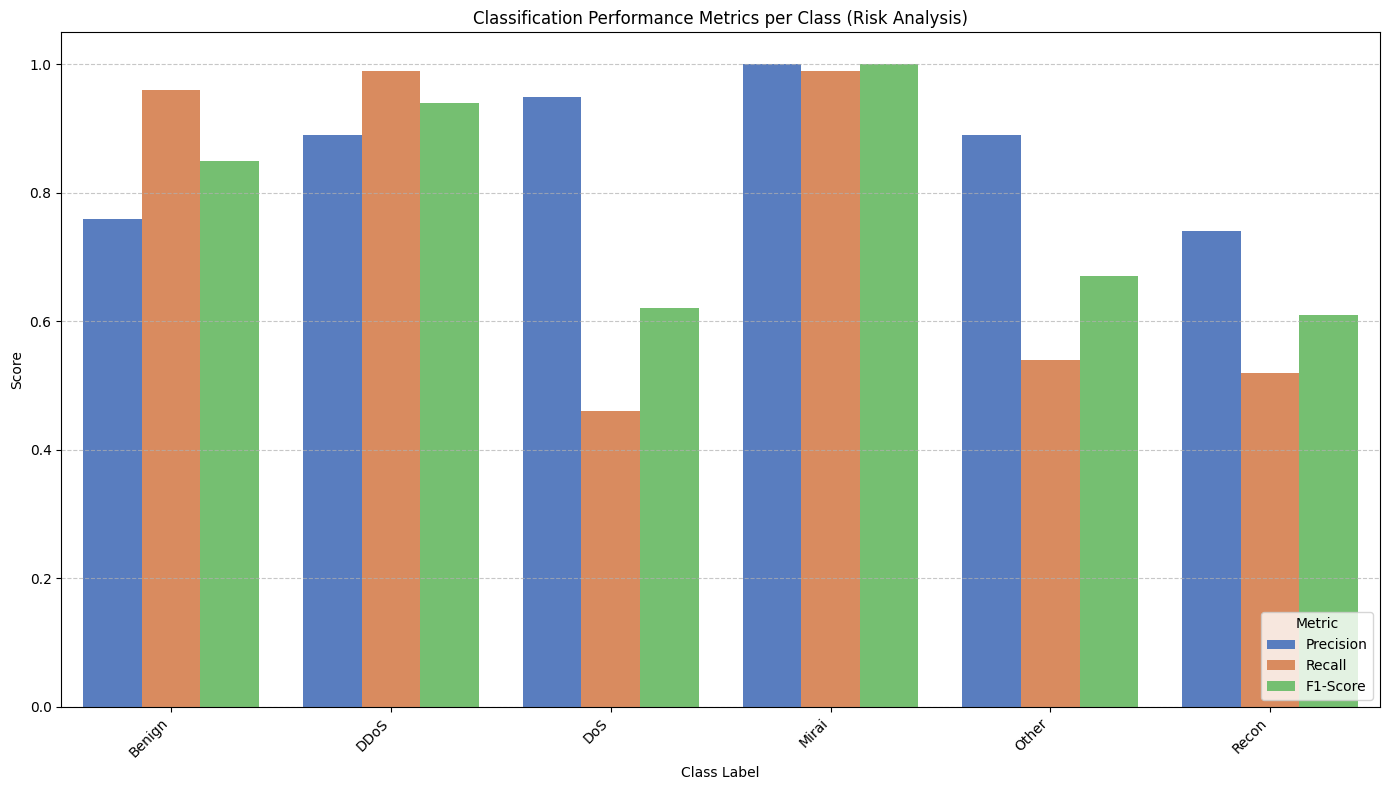

In [14]:
import re
from sklearn.metrics import classification_report

# Re-parse the classification report from the stored output
# This is a bit of a hack but necessary since the report itself isn't returned as a data structure
# In a real scenario, the report would be generated as a dictionary or DataFrame.

# Get the classification report text from the previous output
report_text = """
              precision    recall  f1-score   support

      Benign       0.76      0.96      0.85      1005
        DDoS       0.89      0.99      0.94     31875
         DoS       0.95      0.46      0.62      7513
       Mirai       1.00      0.99      1.00      2542
       Other       0.89      0.54      0.67       504
       Recon       0.74      0.52      0.61       326

    accuracy                           0.89     43765
   macro avg       0.87      0.74      0.78     43765
weighted avg       0.90      0.89      0.88     43765
"""

lines = report_text.strip().split('\n')
# Skip header and accuracy/avg lines
data_lines = [line for line in lines[2:] if not any(kw in line for kw in ['accuracy', 'avg'])]

report_data = []
for line in data_lines:
    parts = re.split(r'\s{2,}', line.strip()) # Split by 2 or more spaces
    if len(parts) == 5:
        label, precision, recall, f1_score, support = parts
        report_data.append({
            'Label': label.strip(),
            'Precision': float(precision),
            'Recall': float(recall),
            'F1-Score': float(f1_score),
            'Support': int(support)
        })

report_df = pd.DataFrame(report_data)

if not report_df.empty:
    # Melt the DataFrame for easier plotting of multiple metrics
    report_melted = report_df.melt(id_vars=['Label', 'Support'], var_name='Metric', value_name='Score')
    report_melted = report_melted[report_melted['Metric'].isin(['Precision', 'Recall', 'F1-Score'])]

    plt.figure(figsize=(14, 8))
    sns.barplot(x='Label', y='Score', hue='Metric', data=report_melted, palette='muted')
    plt.title('Classification Performance Metrics per Class (Risk Analysis)')
    plt.xlabel('Class Label')
    plt.ylabel('Score')
    plt.ylim(0, 1.05) # Scores are between 0 and 1
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Metric', loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print("Could not parse classification report for visualization.")

### Feature Importance for Risk Analysis (SHAP Plots)

Here are the SHAP plots generated previously. These plots illustrate which features are most important in influencing the model's predictions, providing insight into which network attributes contribute most to identifying different types of traffic or attacks. This is crucial for understanding the `risk` indicators the model relies on.

Global Feature Importance (SHAP - Bar Plot):


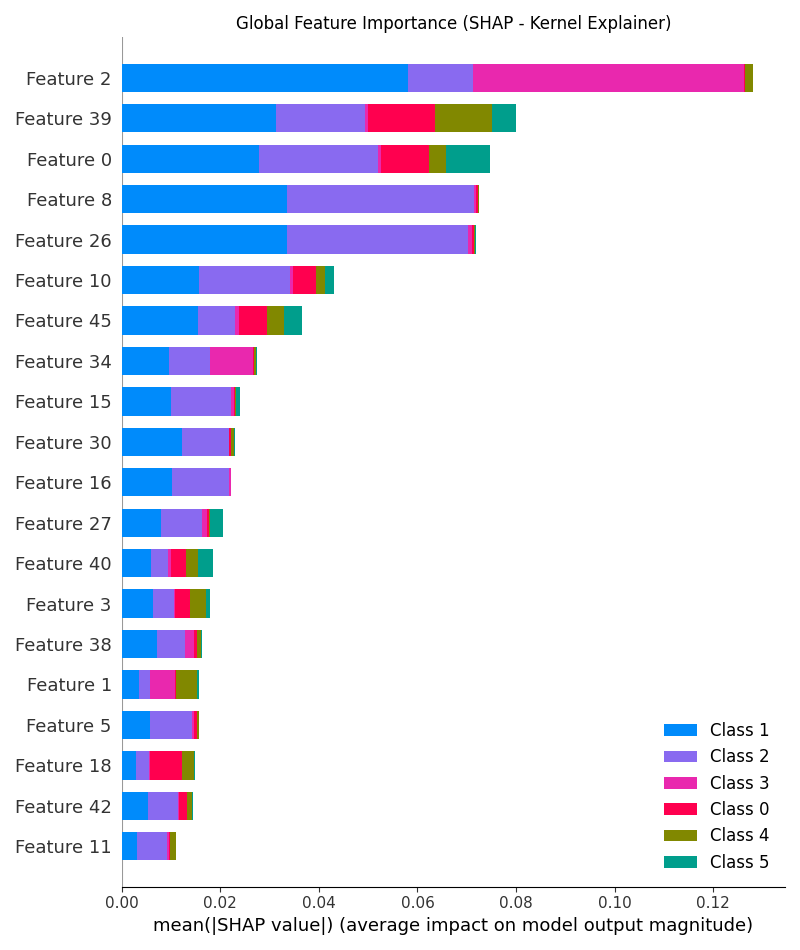


Global SHAP Summary (Dot Plot - Feature Impact on Predictions):


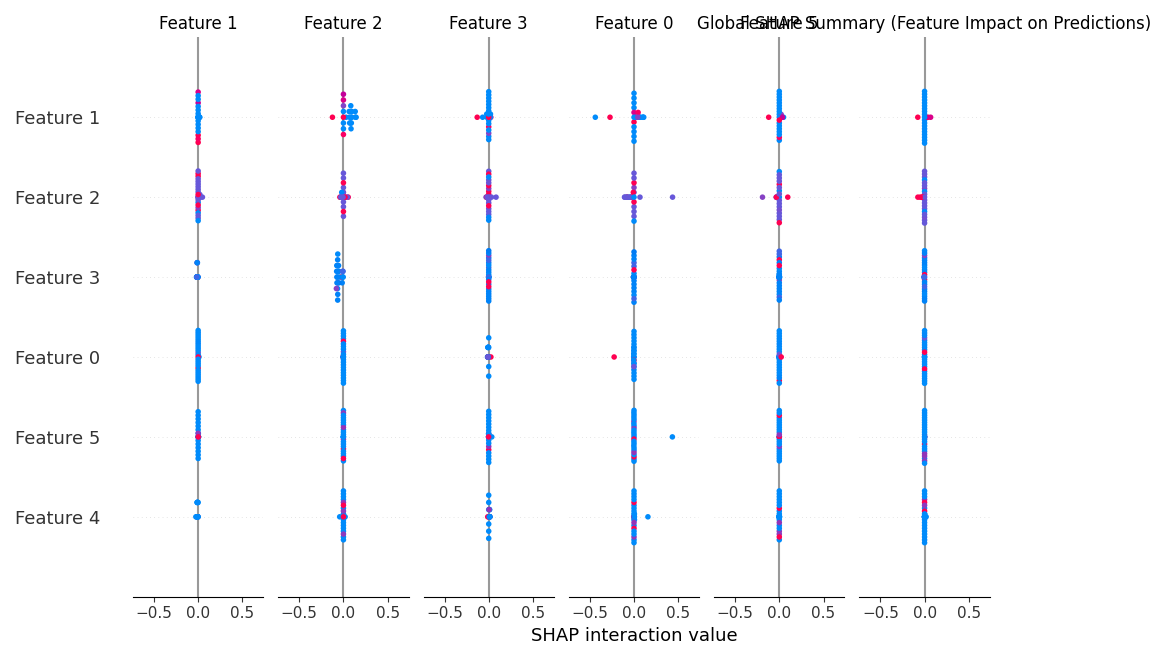

In [15]:
from IPython.display import Image, display

print("Global Feature Importance (SHAP - Bar Plot):")
try:
    display(Image(filename='shap_global_feature_importance_bar.png'))
except FileNotFoundError:
    print("shap_global_feature_importance_bar.png not found. Please ensure SHAP plots were generated successfully.")

print("\nGlobal SHAP Summary (Dot Plot - Feature Impact on Predictions):")
try:
    display(Image(filename='shap_global_summary_dot.png'))
except FileNotFoundError:
    print("shap_global_summary_dot.png not found. Please ensure SHAP plots were generated successfully.")

## Correlation Analysis: Feature Relationships and Target Correlation (for Risk Assessment)

Correlation analysis helps us understand the linear relationships between features and how each feature correlates with the target variable (the different attack types). This is crucial for risk assessment as it can highlight features that are strong indicators of malicious activity.

Loading a larger data sample for correlation analysis...
Loaded 5000 samples for correlation analysis.


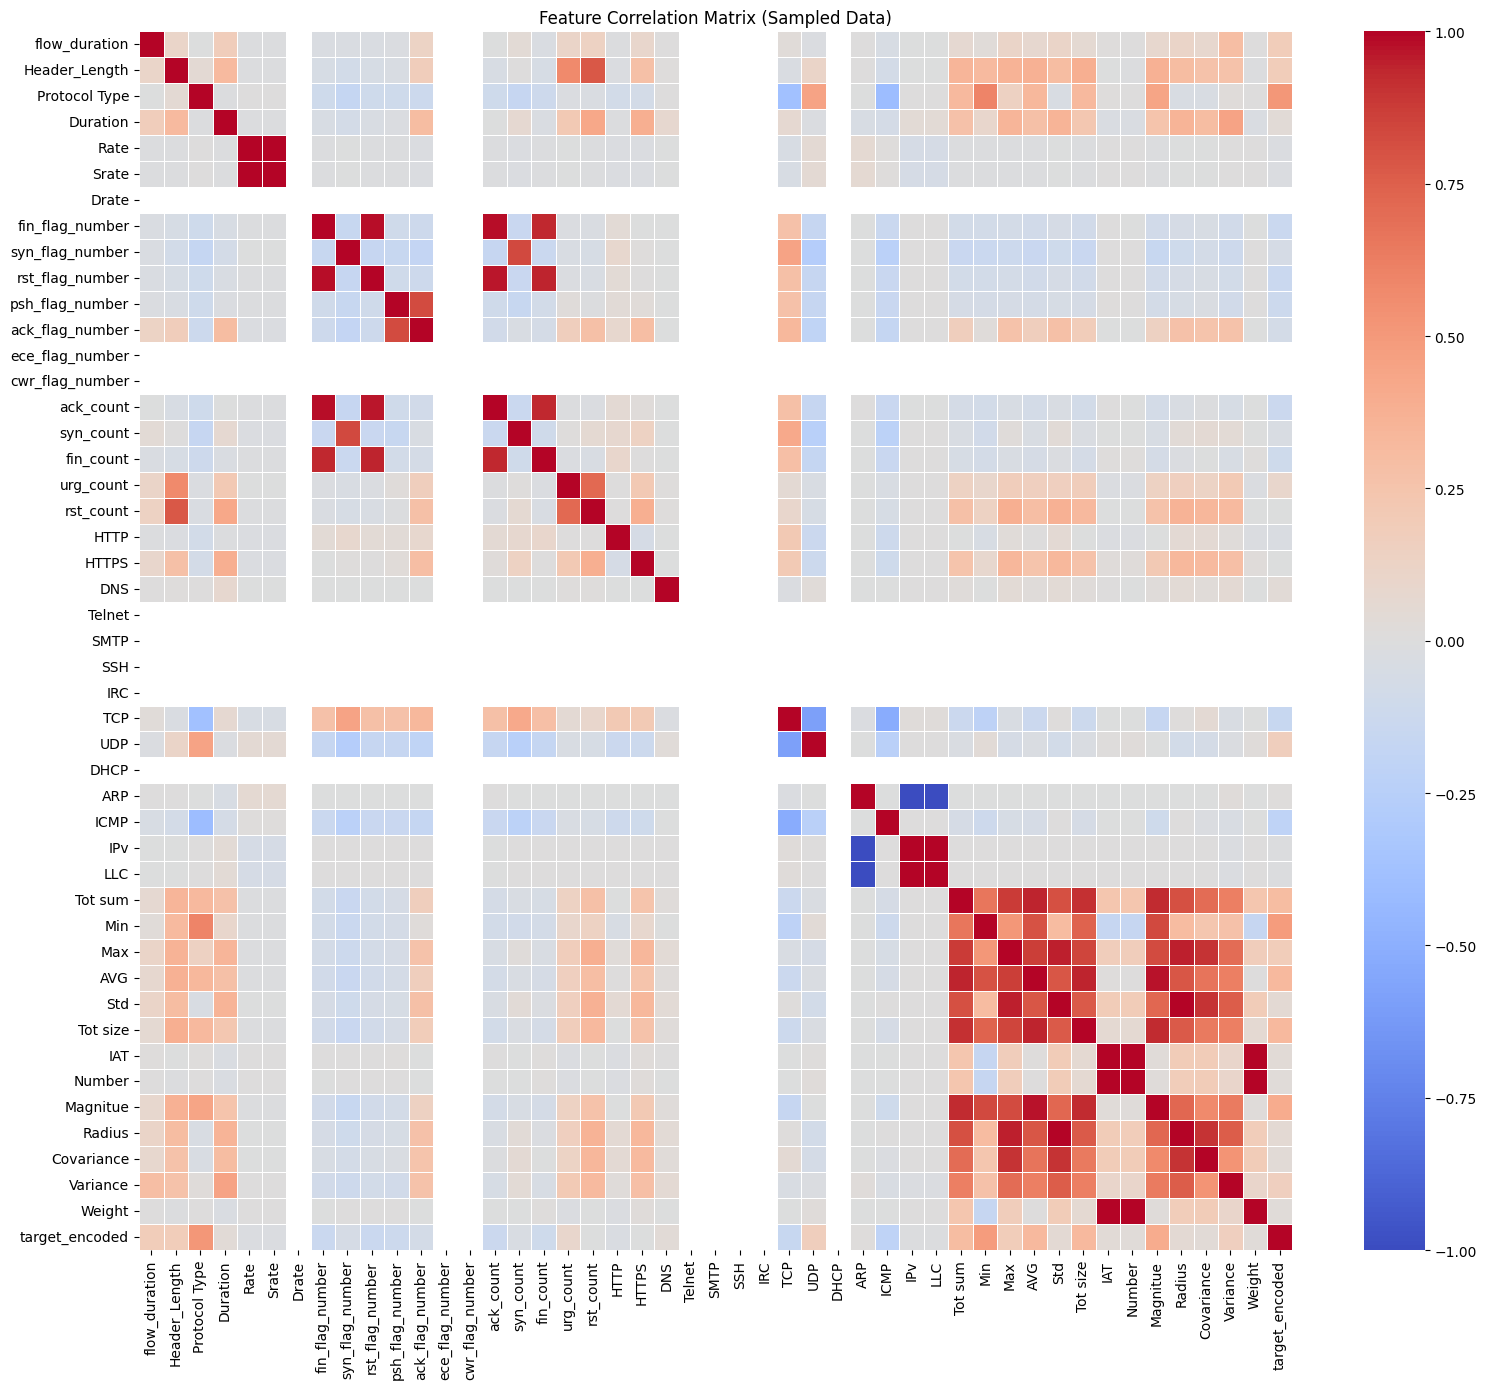


Correlations with Target Variable (Attack Type):
target_encoded     1.000000
Protocol Type      0.511968
Min                0.488353
Magnitue           0.401015
Tot size           0.326534
AVG                0.324086
Tot sum            0.303656
Header_Length      0.184791
flow_duration      0.182204
Max                0.181048
UDP                0.165900
Variance           0.163231
urg_count          0.092812
Radius             0.052241
Std                0.052060
Covariance         0.038055
Duration           0.037156
DNS                0.032828
IAT                0.032145
Number             0.030187
Weight             0.030156
ARP                0.013236
rst_count         -0.001932
HTTPS             -0.004173
LLC               -0.013236
IPv               -0.013236
Rate              -0.017254
Srate             -0.017254
HTTP              -0.030293
syn_count         -0.032122
syn_flag_number   -0.060709
ack_flag_number   -0.075017
fin_count         -0.106309
psh_flag_number   -0.11885

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

# Re-define data_folder if it's not globally accessible
# (It's defined in the __main__ block of the training script)
data_folder = r"CICIoT2023"
file_pattern = "*.csv"

print("Loading a larger data sample for correlation analysis...")

# Similar logic to _get_sample_for_preprocessing to get a larger sample
csv_files = sorted(glob.glob(os.path.join(data_folder, file_pattern)))
if not csv_files:
    raise ValueError(f"No CSV files found in {data_folder}")

sample_size_for_corr = 50000  # Adjust as needed for memory/time
sample_data_frames = []
total_samples_loaded = 0

for csv_file in csv_files:
    if total_samples_loaded >= sample_size_for_corr:
        break
    try:
        # Read a portion of each file, up to the remaining sample_size
        df_temp = pd.read_csv(csv_file, nrows=min(5000, sample_size_for_corr - total_samples_loaded), low_memory=False, on_bad_lines='skip')
        sample_data_frames.append(df_temp)
        total_samples_loaded += len(df_temp)
    except Exception as e:
        print(f"Warning: Could not read {csv_file} for correlation sample due to {e}")
        continue

if not sample_data_frames:
    raise ValueError("No data could be loaded for correlation analysis.")

df_corr_sample = pd.concat(sample_data_frames, ignore_index=True)
print(f"Loaded {len(df_corr_sample)} samples for correlation analysis.")

# --- Replicate Cleaning Steps ---
# Clean object columns (convert to numeric if possible)
for col in df_corr_sample.select_dtypes(include=['object']).columns:
    if col not in ['Label', 'label', 'attack', 'class']:
        df_corr_sample[col] = pd.to_numeric(df_corr_sample[col], errors='coerce')

# Handle inf, NaN, and drop rows with NaNs
df_corr_sample = df_corr_sample.replace([np.inf, -np.inf], np.nan).dropna()

# Identify and drop timestamp columns
timestamp_cols = [c for c in df_corr_sample.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
if timestamp_cols:
    df_corr_sample = df_corr_sample.drop(timestamp_cols, axis=1)

# Identify target column
def _identify_target_column_local(df):
    for c in ['label', 'Label', 'attack', 'Attack', 'class', 'Class']:
        if c in df.columns:
            return c
    return df.columns[-1]

target_col_name = _identify_target_column_local(df_corr_sample)

# Encode the target variable using the previously fitted label_encoder
if target_col_name in df_corr_sample.columns and not df_corr_sample.empty:
    # Use the label_encoder that was saved and loaded (from cell ZecrgsM1Iych)
    # It's assumed 'label_encoder' is available in the kernel namespace from previous runs.

    # First, convert to the 6 classes using the internal mapping logic from the class
    def _convert_to_six_classes_local(y_series):
        y_str = y_series.astype(str).str.lower()
        class_mapping = {}
        for lbl in y_str.unique():
            lbl_low = lbl.lower()
            if any(k in lbl_low for k in ['benign', 'normal', 'legitimate']):
                class_mapping[lbl] = 'Benign'
            elif any(k in lbl_low for k in ['ddos', 'distributed denial']):
                class_mapping[lbl] = 'DDoS'
            elif any(k in lbl_low for k in ['dos', 'denial of service']):
                class_mapping[lbl] = 'DoS'
            elif 'mirai' in lbl_low:
                class_mapping[lbl] = 'Mirai'
            elif any(k in lbl_low for k in ['recon', 'scan', 'portscan', 'hostscan']):
                class_mapping[lbl] = 'Recon'
            else:
                class_mapping[lbl] = 'Other'
        return y_str.map(class_mapping)

    df_corr_sample['target_encoded'] = label_encoder.transform(_convert_to_six_classes_local(df_corr_sample[target_col_name]))
    df_features = df_corr_sample.drop(columns=[target_col_name])

    # Select only numeric columns for correlation
    df_numeric = df_features.select_dtypes(include=np.number)
    df_numeric['target_encoded'] = df_corr_sample['target_encoded']

    # Calculate the correlation matrix
    correlation_matrix = df_numeric.corr()

    plt.figure(figsize=(16, 14))
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Feature Correlation Matrix (Sampled Data)')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Print correlations with the target variable
    print("\nCorrelations with Target Variable (Attack Type):")
    print(correlation_matrix['target_encoded'].sort_values(ascending=False))
else:
    print("No valid data in df_corr_sample for correlation analysis after cleaning.")

In [ ]:
##### Config #####
CONFIG_ROUNDS: int = 7
CONFIG_CLIENTS: int = 5
CONFIG_SHAP_SAMPLE: int = 25
##################

import os
import time
# -------------------------
# Determinism / Reproducibility
# -------------------------
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
random.seed(seed_value)

import numpy as np
np.random.seed(seed_value)

import tensorflow as tf
tf.random.set_seed(seed_value)

try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except Exception:
    pass

# -------------------------
# Imports
# -------------------------
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import shap
import matplotlib.pyplot as plt
import warnings
import glob
import pandas as pd
warnings.filterwarnings('ignore')

# =====================================================
# Federated XAI IDS - Unified Model Comparison
# =====================================================
class FederatedIDSComparer:
    def __init__(self, num_clients=4, input_dim=46, num_classes=6, batch_size=500000):
        self.num_clients = num_clients
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.batch_size = batch_size
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()

    # -----------------------------------------------------
    # Model Architecture 1: Deep MLP
    # -----------------------------------------------------
    def create_mlp_model(self):
        model = keras.Sequential([
            layers.Dense(256, activation='relu', input_shape=(self.input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(64, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(self.num_classes, activation='softmax')
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    # -----------------------------------------------------
    # Model Architecture 2: CNN + LSTM Hybrid
    # -----------------------------------------------------
    def create_cnn_lstm_model(self):
        model = keras.Sequential([
            layers.Reshape((self.input_dim, 1), input_shape=(self.input_dim,)),
            layers.Conv1D(64, 3, activation='relu', padding='same'),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(128, 3, activation='relu', padding='same'),
            layers.Dropout(0.3),
            layers.LSTM(128, return_sequences=False),
            layers.Dropout(0.3),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(self.num_classes, activation='softmax')
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    # -----------------------------------------------------
    # Data Processing Pipeline (runs once)
    # -----------------------------------------------------
    def process_files_in_batches(self, folder_path, file_pattern="*.csv", max_files=8, max_samples=None):
        print("Processing files...")
        csv_files = sorted(glob.glob(os.path.join(folder_path, file_pattern)))
        if not csv_files:
            raise ValueError(f"No CSV files found in {folder_path}")
        csv_files = csv_files[:max_files]

        sample_data = self._get_sample_for_preprocessing(csv_files, sample_size=10000)
        self._fit_preprocessors(sample_data)

        all_client_data = {f'client_{i}': {'X_train': [], 'X_test': [], 'y_train': [], 'y_test': []}
                          for i in range(self.num_clients)}
        total_processed = 0

        for file_idx, csv_file in enumerate(csv_files):
            try:
                for chunk in pd.read_csv(csv_file, chunksize=self.batch_size, low_memory=False):
                    if max_samples and total_processed >= max_samples:
                        break
                    X_processed, y_processed = self._process_chunk(chunk)
                    if X_processed is not None:
                        chunk_client_data = self._split_chunk_among_clients(X_processed, y_processed)
                        for client_id, data in chunk_client_data.items():
                            all_client_data[client_id]['X_train'].append(data['X_train'])
                            all_client_data[client_id]['X_test'].append(data['X_test'])
                            all_client_data[client_id]['y_train'].append(data['y_train'])
                            all_client_data[client_id]['y_test'].append(data['y_test'])
                        total_processed += len(X_processed)
            except Exception as e:
                print(f"Error processing {csv_file}: {e}")
                continue

        final_client_data = []
        for client_id in range(self.num_clients):
            client_key = f'client_{client_id}'
            X_train = np.vstack(all_client_data[client_key]['X_train'])
            X_test = np.vstack(all_client_data[client_key]['X_test'])
            y_train = np.vstack(all_client_data[client_key]['y_train'])
            y_test = np.vstack(all_client_data[client_key]['y_test'])
            final_client_data.append({
                'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test
            })
            print(f"Client {client_id+1}: {len(X_train)} training, {len(X_test)} test samples")
        return final_client_data

    def _get_sample_for_preprocessing(self, csv_files, sample_size=10000):
        sample_data = []
        for csv_file in csv_files:
            try:
                df_sample = pd.read_csv(csv_file, nrows=2000, low_memory=False)
                sample_data.append(df_sample)
            except Exception:
                continue
        return pd.concat(sample_data, ignore_index=True)

    def _fit_preprocessors(self, sample_data):
        sample_data = self._clean_data_chunk(sample_data)
        timestamp_cols = [c for c in sample_data.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
        if timestamp_cols:
            sample_data = sample_data.drop(timestamp_cols, axis=1)
        target_col = self._identify_target_column(sample_data)
        X_sample = sample_data.drop(target_col, axis=1)
        y_sample = sample_data[target_col]
        self.input_dim = X_sample.shape[1]
        y_sample = self._convert_to_six_classes(y_sample)
        self.scaler.fit(X_sample)
        self.label_encoder.fit(y_sample)

    def _process_chunk(self, chunk):
        chunk_clean = self._clean_data_chunk(chunk)
        if chunk_clean.empty:
            return None, None
        timestamp_cols = [c for c in chunk_clean.columns if 'time' in c.lower() or 'timestamp' in c.lower()]
        if timestamp_cols:
            chunk_clean = chunk_clean.drop(timestamp_cols, axis=1)
        target_col = self._identify_target_column(chunk_clean)
        X = chunk_clean.drop(target_col, axis=1)
        y = chunk_clean[target_col]
        y = self._convert_to_six_classes(y)
        X_processed = self.scaler.transform(X)
        y_encoded = self.label_encoder.transform(y)
        y_processed = keras.utils.to_categorical(y_encoded, self.num_classes)
        return X_processed, y_processed

    def _clean_data_chunk(self, df_chunk):
        for col in df_chunk.select_dtypes(include=['object']).columns:
            if col not in ['Label', 'label', 'attack', 'class']:
                try:
                    df_chunk[col] = pd.to_numeric(df_chunk[col], errors='coerce')
                except:
                    pass
        df_chunk = df_chunk.replace([np.inf, -np.inf], np.nan)
        df_chunk = df_chunk.dropna()
        return df_chunk

    def _identify_target_column(self, df):
        for c in ['label', 'Label', 'attack', 'Attack', 'class', 'Class']:
            if c in df.columns:
                return c
        return df.columns[-1]

    def _split_chunk_among_clients(self, X_chunk, y_chunk):
        chunk_size = len(X_chunk)
        samples_per_client = chunk_size // self.num_clients
        client_data = {}
        for i in range(self.num_clients):
            start_idx, end_idx = i * samples_per_client, (i + 1) * samples_per_client
            if i == self.num_clients - 1:
                end_idx = chunk_size
            X_client, y_client = X_chunk[start_idx:end_idx], y_chunk[start_idx:end_idx]
            X_train, X_test, y_train, y_test = train_test_split(
                X_client, y_client, test_size=0.2, random_state=seed_value
            )
            client_data[f'client_{i}'] = {
                'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test
            }
        return client_data

    def _convert_to_six_classes(self, y):
        y_str = y.astype(str).str.lower()
        class_mapping = {}
        for lbl in y_str.unique():
            lbl_low = lbl.lower()
            if any(k in lbl_low for k in ['benign', 'normal', 'legitimate']):
                class_mapping[lbl] = 'Benign'
            elif any(k in lbl_low for k in ['ddos', 'distributed denial']):
                class_mapping[lbl] = 'DDoS'
            elif any(k in lbl_low for k in ['dos', 'denial of service']):
                class_mapping[lbl] = 'DoS'
            elif 'mirai' in lbl_low:
                class_mapping[lbl] = 'Mirai'
            elif any(k in lbl_low for k in ['recon', 'scan', 'portscan', 'hostscan']):
                class_mapping[lbl] = 'Recon'
            else:
                class_mapping[lbl] = 'Other'
        return y_str.map(class_mapping)

    # -----------------------------------------------------
    # Federated Training Pipeline
    # -----------------------------------------------------
    def train_federated_model(self, client_data, model_type="mlp", rounds=5, epochs=10):
        print(f"\nTraining Federated {model_type.upper()} Model...")
        if model_type == "mlp":
            global_model = self.create_mlp_model()
        else:
            global_model = self.create_cnn_lstm_model()

        global_weights = global_model.get_weights()
        round_accuracies = []

        for r in range(rounds):
            client_weights, client_samples = [], []
            for i, data in enumerate(client_data):
                if len(data['X_train']) == 0:
                    continue

                if model_type == "mlp":
                    local_model = self.create_mlp_model()
                else:
                    local_model = self.create_cnn_lstm_model()

                local_model.set_weights(global_weights)
                local_model.fit(
                    data['X_train'], data['y_train'],
                    epochs=epochs, batch_size=256, verbose=0
                )
                client_weights.append(local_model.get_weights())
                client_samples.append(len(data['X_train']))

            # FedAvg Weight Aggregation
            if client_weights:
                new_global_weights = []
                total_samples = sum(client_samples)
                for weights in zip(*client_weights):
                    agg = np.zeros_like(weights[0])
                    for w, n in zip(weights, client_samples):
                        agg += w * (n / total_samples)
                    new_global_weights.append(agg)
                global_weights = new_global_weights
                global_model.set_weights(global_weights)

            # Evaluate at the end of the round
            X_test_all = np.vstack([d['X_test'] for d in client_data if len(d['X_test']) > 0])
            y_test_all = np.vstack([d['y_test'] for d in client_data if len(d['y_test']) > 0])
            _, acc = global_model.evaluate(X_test_all, y_test_all, verbose=0)
            round_accuracies.append(acc)
            print(f"  Round {r+1}/{rounds} Global Accuracy: {acc:.4f}")

        return global_model, round_accuracies

    # -----------------------------------------------------
    # Generate SHAP explanations
    # -----------------------------------------------------
    def apply_shap_explainability(self, model, X_test, model_name="model"):
        print(f"\n📊 Applying Kernel SHAP for {model_name.upper()} Explainability...")
        try:
            sample_size = min(CONFIG_SHAP_SAMPLE, X_test.shape[0])
            rng = np.random.default_rng(seed_value)
            shap_idx = rng.choice(X_test.shape[0], sample_size, replace=False)
            X_shap = X_test[shap_idx]

            background_size = min(100, X_test.shape[0])
            background_idx = rng.choice(X_test.shape[0], background_size, replace=False)
            X_bg = X_test[background_idx]

            explainer = shap.KernelExplainer(model.predict, X_bg)
            shap_vals = explainer.shap_values(X_shap, nsamples=100)

            # Save Bar plot
            plt.figure()
            shap.summary_plot(shap_vals, X_shap, show=False, plot_type="bar")
            plt.title(f"Global Feature Importance ({model_name.upper()})")
            plt.tight_layout()
            plt.savefig(f"shap_{model_name}_feature_importance_bar.png")
            plt.close()

            # Save Dot Summary plot
            plt.figure()
            shap.summary_plot(shap_vals, X_shap, show=False)
            plt.title(f"Global SHAP Summary ({model_name.upper()})")
            plt.tight_layout()
            plt.savefig(f"shap_{model_name}_summary_dot.png")
            plt.close()
            print(f"  SHAP plots saved successfully as 'shap_{model_name}_*.png'")
        except Exception as e:
            print(f"  SHAP explanation failed for {model_name}: {e}")

# =====================================================
# Main Evaluation Pipeline (Deep MLP vs. CNN-LSTM)
# =====================================================
if __name__ == "__main__":
    comparer = FederatedIDSComparer(num_clients=CONFIG_CLIENTS, input_dim=46, num_classes=6, batch_size=500000)
    data_folder = r"CICIoT2023"
    file_pattern = "*.csv"

    try:
        print("==============================================================")
        print("=== COMPARING DEEP MLP VS. CNN-LSTM HYBRID UNDER FEDERATED ===")
        print("==============================================================")

        # Step 1: Process Dataset once for both models
        client_data = comparer.process_files_in_batches(data_folder, file_pattern, max_files=8)
        X_test_all = np.vstack([d['X_test'] for d in client_data])
        y_test_all = np.vstack([d['y_test'] for d in client_data])
        y_true_classes = np.argmax(y_test_all, axis=1)

        # Step 2: Train & Evaluate Deep MLP
        mlp_start = time.time()
        mlp_model, mlp_acc_history = comparer.train_federated_model(
            client_data, model_type="mlp", rounds=CONFIG_ROUNDS, epochs=10
        )
        mlp_time = time.time() - mlp_start
        mlp_preds = mlp_model.predict(X_test_all, verbose=0)
        mlp_pred_classes = np.argmax(mlp_preds, axis=1)
        mlp_report = classification_report(
            y_true_classes, mlp_pred_classes, target_names=comparer.label_encoder.classes_, output_dict=True
        )

        # Step 3: Train & Evaluate CNN-LSTM
        cnn_lstm_start = time.time()
        cnn_lstm_model, cnn_lstm_acc_history = comparer.train_federated_model(
            client_data, model_type="cnn_lstm", rounds=CONFIG_ROUNDS, epochs=10
        )
        cnn_lstm_time = time.time() - cnn_lstm_start
        cnn_lstm_preds = cnn_lstm_model.predict(X_test_all, verbose=0)
        cnn_lstm_pred_classes = np.argmax(cnn_lstm_preds, axis=1)
        cnn_lstm_report = classification_report(
            y_true_classes, cnn_lstm_pred_classes, target_names=comparer.label_encoder.classes_, output_dict=True
        )

        # Save both trained global models
        mlp_model.save("fedxaiids_MLP_TEST.h5")
        cnn_lstm_model.save("fedxaiids_CNNLSTM_TEST.h5")
        print("\nBoth models saved successfully.")

        # Save preprocessing artifacts
        import joblib
        joblib.dump(comparer.scaler, 'scaler_TEST.pkl')
        joblib.dump(comparer.label_encoder, 'label_encoder_TEST.pkl')
        print("Preprocessing objects saved.")

        # =====================================================
        # COMPARATIVE PLOTTING & VISUALIZATION
        # =====================================================
        print("\n📉 Generating Comparative Visualizations...")
        classes = list(comparer.label_encoder.classes_)
        rounds_range = range(1, CONFIG_ROUNDS + 1)

        # Graph 1: Convergence Trend (Accuracy vs Rounds)
        plt.figure(figsize=(8, 5))
        plt.plot(rounds_range, mlp_acc_history, marker='o', label='Deep MLP', color='#1f77b4', linewidth=2)
        plt.plot(rounds_range, cnn_lstm_acc_history, marker='s', label='CNN-LSTM Hybrid', color='#d62728', linewidth=2)
        plt.title('Global Model Accuracy vs. Federated Rounds')
        plt.xlabel('Federated Round')
        plt.ylabel('Global Accuracy')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='lower right')
        plt.tight_layout()
        plt.savefig('comparison_rounds_accuracy.png', dpi=300)
        plt.close()

        # Graph 2: Class-wise F1-Score Comparison
        mlp_f1s = [mlp_report[cls]['f1-score'] for cls in classes]
        cnn_lstm_f1s = [cnn_lstm_report[cls]['f1-score'] for cls in classes]

        x = np.arange(len(classes))
        width = 0.35

        plt.figure(figsize=(10, 6))
        plt.bar(x - width/2, mlp_f1s, width, label='Deep MLP', color='#90caf9')
        plt.bar(x + width/2, cnn_lstm_f1s, width, label='CNN-LSTM Hybrid', color='#ef9a9a')
        plt.title('Class-wise F1-Score Comparison')
        plt.xlabel('Security Attack Class')
        plt.ylabel('F1-Score')
        plt.xticks(x, classes)
        plt.ylim(0, 1.15)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.savefig('comparison_class_f1.png', dpi=300)
        plt.close()

        # Graph 3: Computation Training Time Comparison
        plt.figure(figsize=(6, 5))
        models = ['Deep MLP', 'CNN-LSTM Hybrid']
        times = [mlp_time, cnn_lstm_time]
        colors = ['#90caf9', '#ef9a9a']
        bars = plt.bar(models, times, color=colors, width=0.45)
        plt.title('Total Federated Training Latency')
        plt.ylabel('Seconds (s)')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2.0, height + (max(times)*0.01),
                     f'{height:.1f}s', ha='center', va='bottom', fontweight='bold')
        plt.tight_layout()
        plt.savefig('comparison_training_time.png', dpi=300)
        plt.close()

        # Step 4: Apply SHAP independently for both models to compare explainability
        comparer.apply_shap_explainability(mlp_model, X_test_all, model_name="mlp")
        comparer.apply_shap_explainability(cnn_lstm_model, X_test_all, model_name="cnnlstm")

        print("\n" + "="*50)
        print("🎉 ALL COMPARISONS AND PLOTS GENERATED SUCCESSFULLY!")
        print("Generated files:")
        print(" - comparison_rounds_accuracy.png")
        print(" - comparison_class_f1.png")
        print(" - comparison_training_time.png")
        print(" - shap_mlp_*.png & shap_cnnlstm_*.png")
        print("="*50)

    except Exception as e:
        print(f"Error during comparison pipeline: {e}")
        import traceback
        traceback.print_exc()

=== COMPARING DEEP MLP VS. CNN-LSTM HYBRID UNDER FEDERATED ===
Processing files...
Client 1: 35008 training, 8753 test samples
Client 2: 35008 training, 8753 test samples
Client 3: 35008 training, 8753 test samples
Client 4: 35008 training, 8753 test samples
Client 5: 35008 training, 8753 test samples

Training Federated MLP Model...
  Round 1/7 Global Accuracy: 0.8798
  Round 2/7 Global Accuracy: 0.8851
  Round 3/7 Global Accuracy: 0.9101
  Round 4/7 Global Accuracy: 0.8853
  Round 5/7 Global Accuracy: 0.8879
  Round 6/7 Global Accuracy: 0.8845
  Round 7/7 Global Accuracy: 0.8929

Training Federated CNN_LSTM Model...
